# Customer Churn Analysis

## Tools
- Python
- Google Colab
- Pandas
- Matplotlib
- Seaborn

## Methodology
CRISP-DM

## Objective
Menganalisis faktor-faktor yang mempengaruhi customer churn dan memberikan rekomendasi bisnis untuk meningkatkan retensi pelanggan.

In [21]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [22]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Customer Churn Analysis

## Business Understanding

Perusahaan ingin memahami faktor-faktor yang menyebabkan pelanggan berhenti menggunakan layanan (churn).

Tujuan analisis:

1. Mengetahui tingkat churn pelanggan.
2. Mengidentifikasi karakteristik pelanggan yang churn.
3. Memberikan rekomendasi bisnis untuk meningkatkan retensi pelanggan.

In [23]:
df.shape

(7043, 21)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [25]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

Dataset terdiri dari 7043 pelanggan dengan 21 variabel yang mencakup informasi demografi, layanan yang digunakan, kontrak pelanggan, biaya bulanan, dan status churn.

In [26]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [27]:
df['TotalCharges']

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [28]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [10]:
df.dropna(inplace=True)

In [29]:
df.isnull().sum().sum()

np.int64(11)

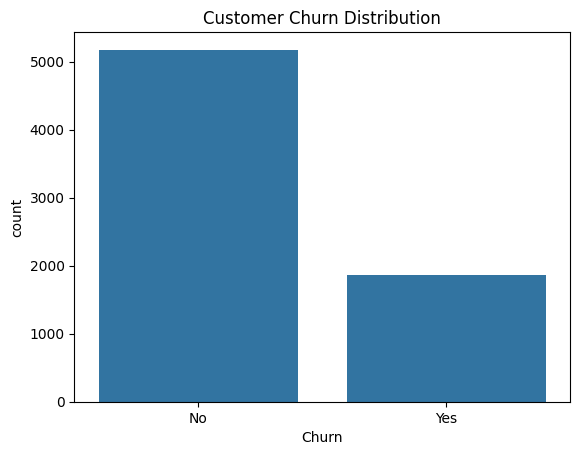

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Customer Churn Distribution')
plt.show()

### Insight

Sebagian besar pelanggan masih bertahan, namun terdapat pelanggan yang melakukan churn sehingga perlu dilakukan analisis lebih lanjut.

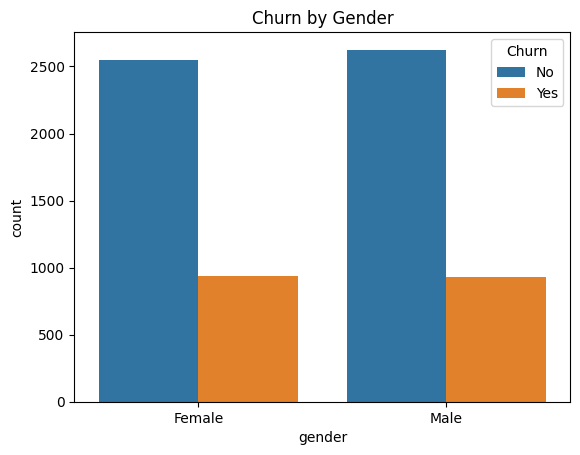

In [31]:

sns.countplot(
    x='gender',
    hue='Churn',
    data=df
)

plt.title('Churn by Gender')
plt.show()

### Insight

Tidak terdapat perbedaan signifikan antara pelanggan laki-laki dan perempuan terhadap tingkat churn.

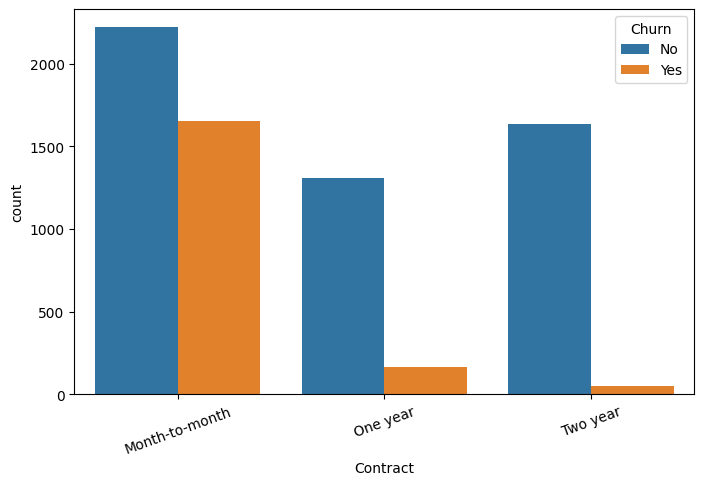

In [14]:

plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn',
    data=df
)

plt.xticks(rotation=20)
plt.show()

### Insight

Pelanggan dengan kontrak Month-to-Month memiliki tingkat churn tertinggi dibandingkan kontrak satu tahun maupun dua tahun.

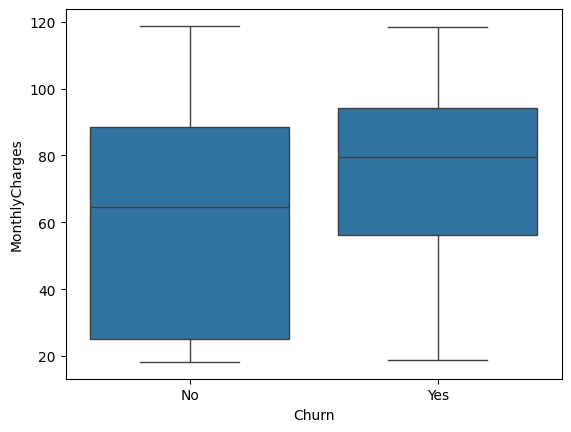

In [15]:
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.show()

### Insight

Pelanggan dengan biaya bulanan yang lebih tinggi cenderung memiliki risiko churn lebih besar.

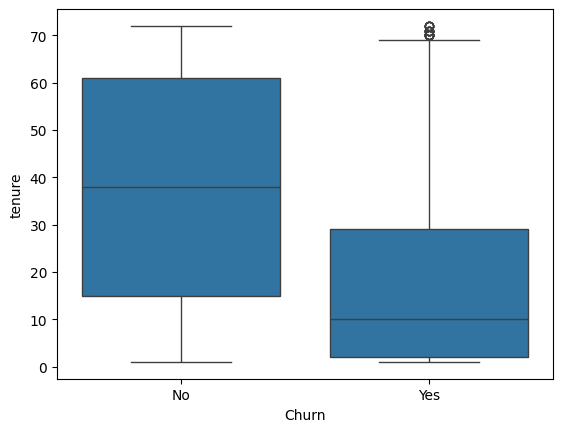

In [16]:
sns.boxplot(
    x='Churn',
    y='tenure',
    data=df
)

plt.show()

### Insight

Pelanggan yang baru bergabung memiliki kemungkinan churn lebih tinggi dibanding pelanggan lama.

In [18]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(churn_rate)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


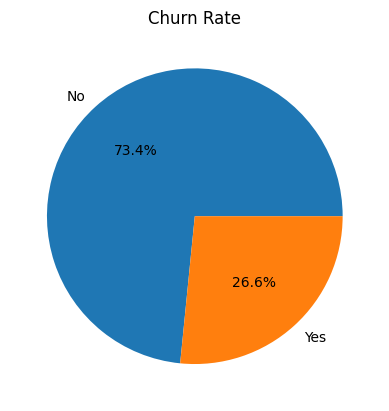

In [19]:
churn_rate.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Churn Rate')
plt.show()

# Kesimpulan

1. Tingkat churn pelanggan cukup signifikan.
2. Pelanggan dengan kontrak Month-to-Month memiliki risiko churn tertinggi.
3. Pelanggan baru lebih rentan melakukan churn.
4. Biaya bulanan yang tinggi berkorelasi dengan peningkatan churn.

# Rekomendasi

1. Menawarkan diskon untuk kontrak tahunan.
2. Membuat program retensi pelanggan baru.
3. Meninjau kembali struktur harga layanan premium.